In [1]:
import os
import rasterio
from matplotlib import pyplot as plt
from smosaic.smosaic_mosaic import mosaic

In [ ]:
# Configurações de diretórios
output_dir = os.path.abspath("./output_jupyter")
data_dir = os.path.abspath("./tmp_jupyter")

# --- CORREÇÃO: Criar as pastas caso não existam ---
os.makedirs(output_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
# -------------------------------------------------
bbox = "-45.865,-23.215,-45.855,-23.205"
# Executa o mosaico
mosaic(
    name="Teste_Jupyter",
    data_dir=data_dir,
    stac_url="https://data.inpe.br/bdc/stac/v1",
    collection="S2_L2A-1",
    bbox=bbox,  # Agora passando como String
    output_dir=output_dir,   
    mosaic_method="lcf", 
    start_year=2023,
    start_month=1,
    start_day=1,
    duration_days=30,
    bands=["B04", "B03", "B02"]
)

Downloading... : 100%|██████████| 24/24 [11:35<00:00, 28.98s/ itens]

Successfully download 24 files to S2_L2A-1
--- Starting parallel processing with 8 processes. ---



[Process 31510] Starting to process period: 2023-01-01 to 2023-01-30



Processing B04...: 100%|██████████| 24/24 [00:55<00:00,  2.32s/it]


Raster saved to: /home/matheus-sales/Documents/introd atv/smosaic/output_jupyter/S2_L2A-TESTE_JUPYTER-30D-B04_20230101_20230130_COG.tif
Raster saved to: /home/matheus-sales/Documents/introd atv/smosaic/output_jupyter/S2_L2A-TESTE_JUPYTER-30D_SCL_20230101_20230130_COG.tif
Raster saved to: /home/matheus-sales/Documents/introd atv/smosaic/output_jupyter/S2_L2A-TESTE_JUPYTER-30D-PROVENANCE_20230101_20230130_COG.tif


Processing B03...: 100%|██████████| 24/24 [00:40<00:00,  1.70s/it]


Raster saved to: /home/matheus-sales/Documents/introd atv/smosaic/output_jupyter/S2_L2A-TESTE_JUPYTER-30D-B03_20230101_20230130_COG.tif


Processing B02...: 100%|██████████| 24/24 [00:40<00:00,  1.68s/it]


Raster saved to: /home/matheus-sales/Documents/introd atv/smosaic/output_jupyter/S2_L2A-TESTE_JUPYTER-30D-B02_20230101_20230130_COG.tif


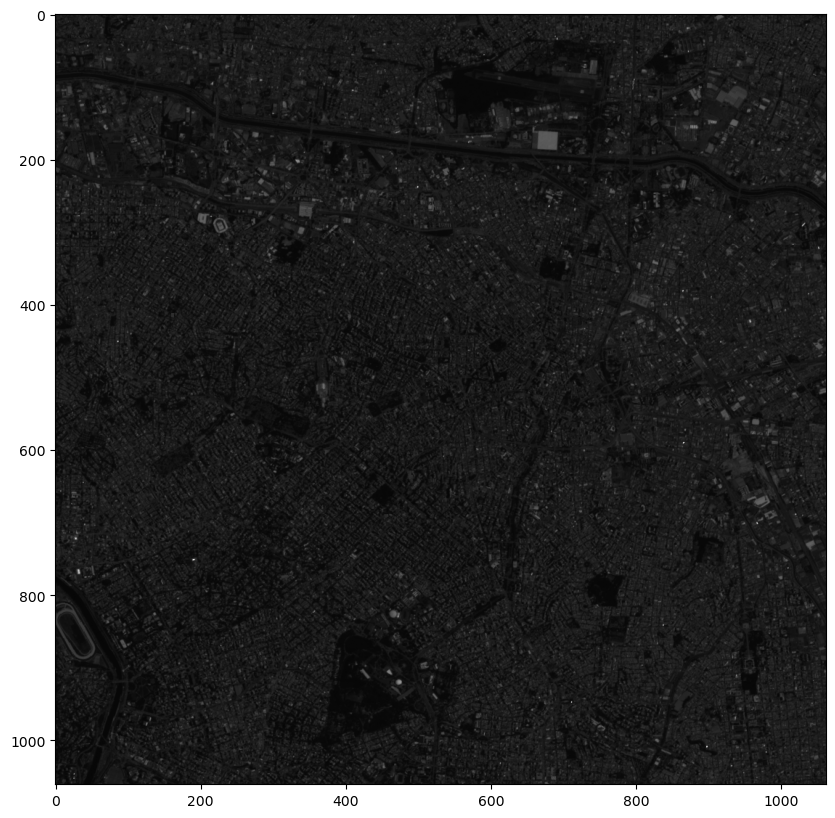

In [46]:
# Visualização rápida do resultado (opcional)
import glob
tifs = glob.glob(os.path.join(output_dir, "*B04*.tif")) # Procura a banda vermelha
if tifs:
    with rasterio.open(tifs[0]) as src:
        plt.figure(figsize=(10, 10))
        plt.imshow(src.read(1), cmap='gray')
        plt.show()